# The ETF "on sale" trade — does buying below NAV pay? ⚖️
### When a fund's price dips under the value of what it owns, is that free money?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_discount%3F: Busted](https://img.shields.io/badge/Free_discount%3F-Busted-8b949e?style=flat-square)

Here's a tidy-sounding idea. An ETF is just a basket of bonds (or stocks). Each day the fund tells you the **NAV** — the value of everything inside. Sometimes the ETF's *price* dips **below** that NAV: the wrapper is cheaper than its contents. Lore says that's a **discount on sale** — the gap *has* to close, so buy the discount and pocket it when it snaps back. The bond-ETF crash of **March 2020** (HYG, EMB, MUB all printing big discounts) is Exhibit A.

It sounds like arbitrage. But two things have to be true for it to *pay*: the gap has to close **in your pocket** (not just because the whole bond market bounced), and the snap-back has to be **bigger than the spread** you cross getting in and out. This notebook checks both — and the answer is that the discount is real arithmetic, not free money.

> 📓 **Plain-language layer.** Want the *t*-stats, the hedge, the cost sweep and the stress-clustering test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The official intraday NAV isn't free on yfinance, so we **build a transparent proxy**: a fair value for each ETF from a sister fund + a rates leg. We call it a proxy throughout — but a *tighter*, real NAV would only make the gap **smaller** and the verdict stronger. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_nav_premium import data, strategy as st

HAVE_REAL = data.have_real()
FRAMES = data.load_real() if HAVE_REAL else None
print("real ETF-price cache present:", HAVE_REAL,
      "| target ETFs:", (list(FRAMES) if FRAMES else None))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2012-01-03', 'end': '2026-06-18', 'days': 3636, 'years': 14.5, 'targets': ['HYG', 'EMB', 'MUB'], 'pool': [(5, 1664, 0.0525, 56, 2.03), (10, 1663, 0.0496, 54, 1.24), (20, 1663, 0.0543, 53, 0.92)], 'per': {'HYG': (504, -0.27, -0.0119, 45, -0.58, 0.978), 'EMB': (597, -1.47, 0.0696, 54, 0.67, 0.028), 'MUB': (562, -0.36, 0.0835, 64, 2.4, 0.0)}, 'costs': [(1.0, 0.04, 0.0125), (2.0, 0.08, -0.0275), (3.0, 0.12, -0.0675)], 'robust': [(-0.5, 3047, 0.0441, 56, 2.83), (-1.0, 1664, 0.0525, 56, 2.03), (-1.5, 846, 0.0654, 56, 1.53), (-2.0, 403, 0.1338, 58, 1.74)], 'stress': {'HYG': (24, -1.04, '2016-05-09'), 'EMB': (22, -9.31, '2020-03-18'), 'MUB': (25, -4.43, '2020-03-18')}, 'syn': [(0.0, 576, -0.0642, -1.17, 0.989), (5.0, 576, 0.1702, 3.1, 0.001)]}


real ETF-price cache present: True | target ETFs: ['HYG', 'EMB', 'MUB']


## The answer first

| Question | Answer |
|---|---|
| After a discount, does the gap shrink? | **Partly, yes.** Buy when the ETF is cheap to fair value and on average the gap closes a little over the next week. |
| So you earn the discount back? | **Barely.** Once you strip out the bond market's own move, the *harvest* is about **0/100ths of a percent** (~5 basis points) — and it fades to nothing within two weeks. |
| Does it beat trading costs? | **No.** The bid-ask you cross — on the ETF *and* the hedge — is the same size as the whole harvest. At a routine 2-bp spread the trade is already **net negative**. |
| Then why does everyone remember it working? | **March 2020.** The biggest discounts all cluster in that one crisis — when the machinery that closes the gap **broke** and you *couldn't* trade at NAV anyway. The vivid case is the un-tradable one. |

> The discount is real — but it's mostly the basket moving, what reverts is pennies, costs eat it, and the giant gaps show up exactly when you can't use them. "On sale" is a story.

## 1 · The claim

> *"An ETF that trades below its NAV is cheaper than the things it holds. That discount is a free gap — the price and the NAV must converge — so buy the discount, wait, and collect the difference. Bond ETFs in March 2020 traded at huge discounts and then recovered: textbook."*

The picture is seductive because the discount is a **real, published number** — every ETF reports its premium/discount daily, and during stress bond ETFs *did* trade percentage points below NAV. The leap is from *"the gap exists and is reported"* to *"the gap is free money you can harvest."* We'll rebuild the discount and put that leap under a microscope, on the funds where the gap is biggest: **HYG** (high yield), **EMB** (emerging markets), **MUB** (munis).

## 2 · So what?

If "buy the discount" really paid, it would be a rare thing: a **structural** edge, baked into how ETFs are wrapped, available to anyone with a brokerage account — not a fragile pattern but a mechanical one. That's why it's tempting.

But notice the trap hiding in the word *discount*. When an ETF is 1% below NAV, that gap can close two ways: the **ETF rises** to meet NAV (you win) — or the **NAV falls** to meet the ETF (you don't). For bond ETFs the NAV is partly **stale** (many bonds don't trade every day), so a "discount" often means the ETF has *already* spotted a markdown the NAV hasn't caught up to. Buying that isn't buying a bargain — it can be buying **ahead of a drop**. The only honest test is: net of the whole bond market moving, and net of costs, does the buyer actually come out ahead?

## 3 · How would we even know?

We rebuild the discount on a **transparent NAV proxy**. For each ETF we build a fair value from a sister fund + a rates leg, and define the **basis** = how far the ETF has drifted from that fair value (positive = rich/**premium**, negative = cheap/**discount**). Over **14 years** (2012-01-03 → 2026-06-18) we then:

1. **Mark the discounts.** Flag every day the ETF is unusually cheap (basis well below its own recent average).
2. **Measure the *hedged* harvest.** Enter the next day, hold a week or two, and bank the ETF's move **minus** the fair-value basket's move — so we measure the *gap closing*, not *the bond market rallying*.
3. **Charge the spread, and look at the crises.** Net the harvest against a realistic bid-ask on both legs, and check *when* the biggest discounts actually happen.

## 4 · The teardown — let's actually look

**First, here's a discount.** The premium/discount basis for one ETF — drifting rich and cheap around fair value. The deep dive in early 2020 is the famous bond-ETF dislocation.

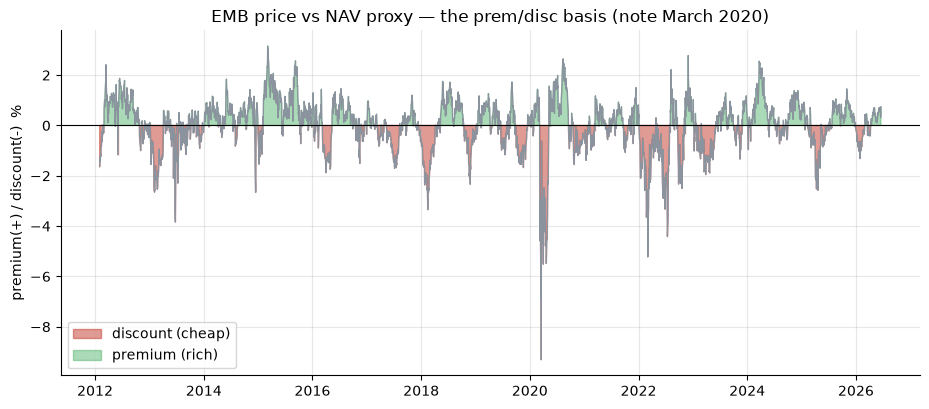

deepest EMB discount: -9.31% on 2020-03-18


In [2]:
if HAVE_REAL:
    f = FRAMES['EMB']; b = f['basis']*100
    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    ax.plot(b.index, b.values, c=GREY, lw=.9)
    ax.fill_between(b.index, b.values, 0, where=(b.values<0), color=RED, alpha=.5, label='discount (cheap)')
    ax.fill_between(b.index, b.values, 0, where=(b.values>0), color=GREEN, alpha=.4, label='premium (rich)')
    ax.axhline(0, c='k', lw=.8)
    ax.set_title('EMB price vs NAV proxy — the prem/disc basis (note March 2020)')
    ax.set_ylabel('premium(+) / discount(-)  %'); ax.legend()
    plt.tight_layout(); plt.show()
    print('deepest EMB discount:', f'{b.min():.2f}%', 'on', b.idxmin().date())
else:
    print('no cache — see docs/results.md; EMB worst discount', R['stress']['EMB'][1], '% on', R['stress']['EMB'][2])

Vivid — and look *where* the worst gap is: **-9.3% on 2020-03-18**, the COVID liquidity crunch. Hold that thought. Now the real question: after a discount, what does the buyer actually take home?

**The harvest vs the bid-ask.** For each hold length, the *hedged* discount earn-back (pooled across the three ETFs) next to a realistic round-trip cost. The harvest is the green bar; the dashed line is what you pay to trade.

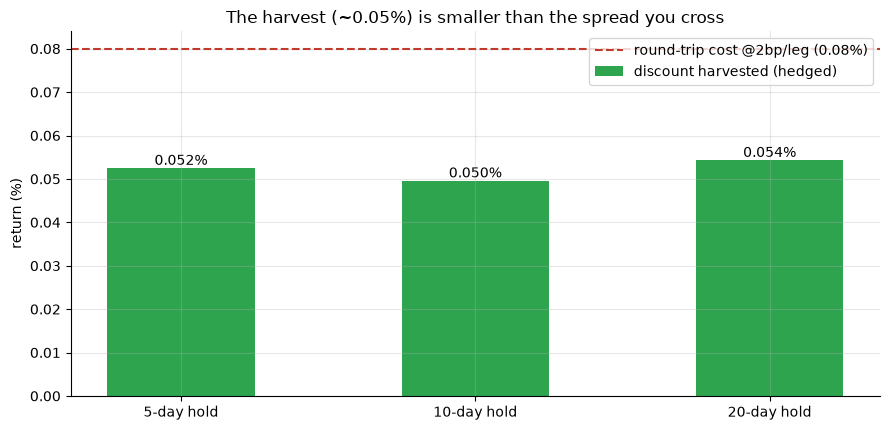

harvest by horizon (%): {'5d': 0.0525, '10d': 0.0496, '20d': 0.0543} | 2bp round-trip: 0.08%


In [3]:
hs = [h for h,*_ in R['pool']]
if HAVE_REAL:
    harv = [st.pooled_harvest(FRAMES, h)['harvest_mean']*100 for h in hs]
else:
    harv = [p[2] for p in R['pool']]
cost2 = R['costs'][1][1]   # 2bp/leg round-trip cost, %
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(hs))
ax.bar(x, harv, .5, color=GREEN, label='discount harvested (hedged)')
ax.axhline(cost2, ls='--', c=RED, label=f'round-trip cost @2bp/leg ({cost2:.2f}%)')
ax.set_xticks(x); ax.set_xticklabels([f'{h}-day hold' for h in hs])
ax.set_ylabel('return (%)'); ax.set_title('The harvest (~0.05%) is smaller than the spread you cross')
for i,v in enumerate(harv): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('harvest by horizon (%):', {f'{h}d': round(v,4) for h,v in zip(hs,harv)}, '| 2bp round-trip:', f'{cost2:.2f}%')

There's the whole story in one chart. The discount earn-back is about **0.052%** — five hundredths of a percent — and the cost of getting in and out is **0.08%**, *bigger than the harvest*. You are crossing a spread to collect less than the spread. And it gets worse: most of the apparent 'discount' was just the bond market dropping (which we hedged out), so the raw, unhedged 'snap-back' is mostly borrowed from beta you were carrying anyway.

**Does it even work the same way on each ETF?** A real structural edge should show up everywhere. Here's the hedged earn-back per fund — watch one of them go the *wrong* way.

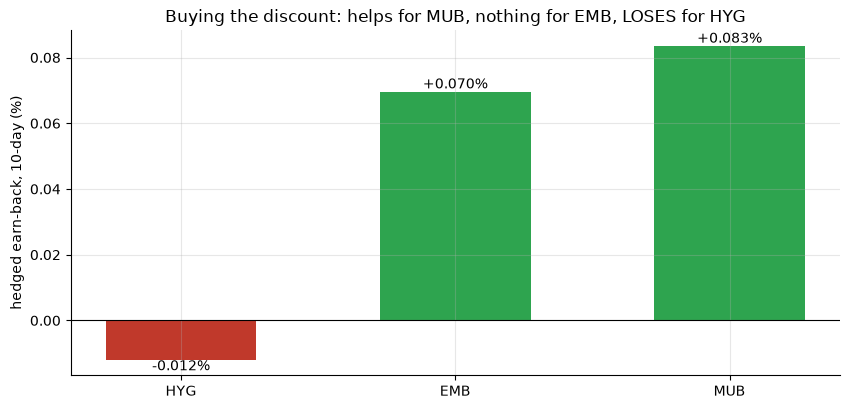

per-ETF 10d harvest (%): {'HYG': -0.0119, 'EMB': 0.0696, 'MUB': 0.0835}


In [4]:
names = R['targets']
if HAVE_REAL:
    vals = []
    for tg in names:
        ev = st.detect_discounts(FRAMES[tg]); s = st.summarize(FRAMES[tg], ev, 10)
        vals.append(s['harvest_mean']*100)
else:
    vals = [R['per'][tg][2] for tg in names]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(names, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(vals): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('hedged earn-back, 10-day (%)')
ax.set_title('Buying the discount: helps for MUB, nothing for EMB, LOSES for HYG')
plt.tight_layout(); plt.show()
print('per-ETF 10d harvest (%):', {tg: round(v,4) for tg,v in zip(names, vals)})

That's the tell. **HYG's discount earn-back is *negative*** (**-0.012%**): buying high-yield when it looks cheap, hedged, **loses** money. EMB is a coin-flip. Only **MUB** carries the pooled number. A 'free discount' that *reverses sign* across the funds it's meant to describe isn't a structural law — it's three noisy series, one of which happened to wobble up.

## 5 · The verdict

- **Signal — Weak.** The discount *does* partly close — but the hedged harvest is ~5 bp, fades within two weeks, and **flips negative on HYG**. Real as a wobble, weak as an edge.
- **Tradability — Mirage.** The harvest is **smaller than the bid-ask** on two legs (net-negative at a normal 2-bp spread), and the biggest discounts hit in **stress**, when the gap-closing machinery is broken.
- **"Free discount"? — Busted.** Below-NAV isn't 'on sale': most of the gap is the basket moving, what reverts is pennies, costs erase it, and the headline crises are exactly the moments you *can't* trade it.

## 6 · Could you actually trade it? — the crisis trap

Forget the basis points for a second. The deeper problem is *when* the big discounts happen. If they were sprinkled evenly through calm markets you could at least try to harvest them. They aren't. Here's where each ETF's **deepest** discounts land on the calendar.

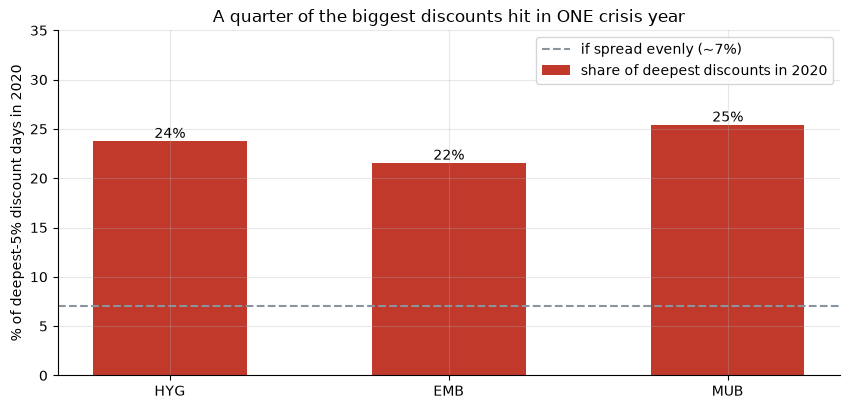

share of deepest discounts in 2020 (%): {'HYG': 24, 'EMB': 22, 'MUB': 25} | uniform ~7%


In [5]:
names = R['targets']
if HAVE_REAL:
    shares = []
    for tg in names:
        b = FRAMES[tg]['basis']; deep = b[b < b.quantile(0.05)]
        shares.append((deep.index.year==2020).mean()*100)
else:
    shares = [R['stress'][tg][0] for tg in names]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(names, shares, color=RED, width=.55, label='share of deepest discounts in 2020')
ax.axhline(7, ls='--', c=GREY, label='if spread evenly (~7%)')
for i,v in enumerate(shares): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('% of deepest-5% discount days in 2020'); ax.set_ylim(0, 35)
ax.set_title('A quarter of the biggest discounts hit in ONE crisis year'); ax.legend()
plt.tight_layout(); plt.show()
print('share of deepest discounts in 2020 (%):', {tg: round(s) for tg,s in zip(names, shares)}, '| uniform ~7%')

Around **a quarter** of every ETF's worst discounts fall in **2020** — roughly **3× more** than if they were spread evenly. That's the cruel joke of the trade: the discount is tiny and un-harvestable when markets are calm, and *enormous* exactly when the creation/redemption arbitrage has frozen, the underlying bonds aren't trading, and the 'NAV' you're comparing to is itself stale. The romantic version — 'wait for a giant discount and back up the truck' — is the version you **can't execute**.

## 7 · Going further 🚪

- **Use a real NAV.** Swap our hedge-basket proxy for a fund's published daily NAV (from the issuer or a paid feed) and re-run — the gap will be *tighter* and the harvest *smaller*, because the true creation/redemption arb is faster than our proxy.
- **Try equity ETFs.** SPY/IVV trade within a basis point of NAV all day — there's nothing to harvest. The discount story only *looks* alive on illiquid underlyings (HY, EM, munis), which is exactly where costs and stale NAVs bite hardest.
- **Separate stale-NAV from mispricing.** Build the test around *next-day NAV* to see how much of the 'discount' is the NAV catching down to a price the ETF already found.

*Think the below-NAV trade pays after costs? Hedge out the basket, charge both legs the spread, and show a harvest that survives **outside** March 2020 — then we'll talk.*